# 🌸 Task 1 · Iris Flower Classification

**Oasis Infobyte Internship (OIBSIP) · Data Science Track**
**Intern:** Vinay Singh Chaudhary  |  **Batch:** 5 Oct – 15 Nov 2026

---

### 🎯 Objective
Train a machine-learning **classification model** that identifies the species of an iris flower —
*Setosa*, *Versicolor* or *Virginica* — from four physical measurements (sepal length/width, petal length/width).

### 🗺️ Workflow
| # | Step | What happens |
|---|------|--------------|
| 1 | Setup | Import libraries, fix random seed |
| 2 | Load data | `sklearn.datasets.load_iris()` — no download needed |
| 3 | EDA | shape, dtypes, nulls, descriptive statistics, class balance |
| 4 | Visualise | pairplot, box plots, correlation heatmap |
| 5 | Feature discussion | which features separate the species best? |
| 6 | Split | stratified 80 / 20 train–test split |
| 7 | Model | Logistic Regression, KNN, Decision Tree, Random Forest, SVM |
| 8 | Evaluate | accuracy, confusion matrix, classification report, 5-fold CV |
| 9 | Conclude | declare & justify the best model, predict a new flower |

## 1️⃣ Setup — import libraries

In [ ]:
# ---------------------------------------------------------------
# Core data-handling libraries
# ---------------------------------------------------------------
import os                      # to create the outputs/ folder for saved charts
import warnings                # to keep the notebook output clean
import numpy as np             # numerical arrays
import pandas as pd            # tabular data (DataFrames)

# ---------------------------------------------------------------
# Visualisation libraries
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# Machine-learning tools from scikit-learn
# ---------------------------------------------------------------
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")   # consistent, clean chart style
RANDOM_STATE = 42                                  # fixed seed → reproducible results
os.makedirs("outputs", exist_ok=True)              # every chart is also saved here
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2️⃣ Load the dataset
`load_iris()` returns the classic dataset collected by botanist Edgar Anderson and made famous by R. A. Fisher (1936):
**150 flowers, 4 numeric features, 3 balanced classes (50 each)**.

In [ ]:
# Load the dataset bundled with scikit-learn (as_frame=True gives us pandas objects)
iris = load_iris(as_frame=True)

# Build one tidy DataFrame: 4 feature columns + a readable 'species' column
df = iris.frame.copy()
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "target"]
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Key Observations & Technical Insights

-   **Tabular Structure:** The dataset comprises 150 instances and 4
    continuous numerical feature columns alongside the encoded target
    and categorical species name.
-   **Feature Scope:** Measurements capture morphology across two
    botanical organs: sepals (protective outer calyx) and petals (inner
    corolla), recorded in centimeters.
-   **Integrity:** Initial records demonstrate clean numeric scaling
    with no anomalous negative or zero-value measurements.


## 3️⃣ Exploratory Data Analysis (EDA)
### 3.1 Shape, data types and missing values

In [ ]:
print("Shape of dataset  :", df.shape)            # (rows, columns)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows    :", df.duplicated().sum())

Shape of dataset  : (150, 6)

Data types:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
target            int64
species          object
dtype: object

Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
species         0
dtype: int64

Duplicate rows    : 1


### Key Observations & Technical Insights

-   **Zero Missing Data:** All 150 rows contain complete entries across
    every feature column (`0 nulls`), eliminating the need for missing
    value imputation.
-   **Data Types:** Features are consistently stored as double-precision
    floating-point numbers (`float64`), ready for direct numerical
    processing and matrix operations.
-   **Duplicate Record Handling:** A single duplicate row exists in the
    dataset (row indices with identical measurements). In physical
    taxonomy datasets of this scale, identical physical measurements
    among individual specimens are biologically plausible; retaining
    this instance avoids introducing artificial sampling bias.

> **Observation:** 150 rows × 6 columns, all features are `float64`, and there are **no missing values**.
> One duplicated row exists — this is a genuine repeated measurement in the original data, so we keep it.

### 3.2 Descriptive statistics & class balance

In [ ]:
# Summary statistics of the 4 numeric features
display(df.drop(columns="target").describe().T.round(2))

# How many flowers of each species? (checks class imbalance)
print("Class distribution:")
print(df["species"].value_counts())

,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.06,0.44,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.76,1.77,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5


Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
# Mean of every feature per species – a first hint of which features separate the classes
df.groupby("species")[["sepal_length", "sepal_width", "petal_length", "petal_width"]].mean().round(2)

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


### Key Observations & Technical Insights

-   **Perfect Class Balance:** The dataset consists of exactly 50
    samples per species (33.3% Setosa, 33.3% Versicolor, 33.3%
    Virginica). This removes class imbalance bias and validates
    **Accuracy** as a reliable primary evaluation metric alongside Macro
    F1.
-   **Measurement Variance:** Petal length displays the highest standard
    deviation (1.77 cm) and largest dynamic range (1.0 cm to 6.9 cm),
    indicating wide spread across the categories.
-   **Group Means Divergence:**
    -   *Setosa* has markedly smaller petals (mean length 1.46 cm, mean
        width 0.25 cm) combined with wider sepals (mean 3.43 cm).
    -   *Versicolor* occupies an intermediate scale (petal length 4.26
        cm, petal width 1.33 cm).
    -   *Virginica* exhibits the largest overall dimensions (petal
        length 5.55 cm, petal width 2.03 cm).

> **Observation:** The classes are perfectly balanced (50 / 50 / 50), so **accuracy is a fair metric**.
> Petal measurements differ hugely between species (Setosa petals ≈ 1.5 cm vs Virginica ≈ 5.6 cm), while sepal width barely changes.

## 4️⃣ Visualisations
### 4.1 Pairplot — every feature against every other, coloured by species

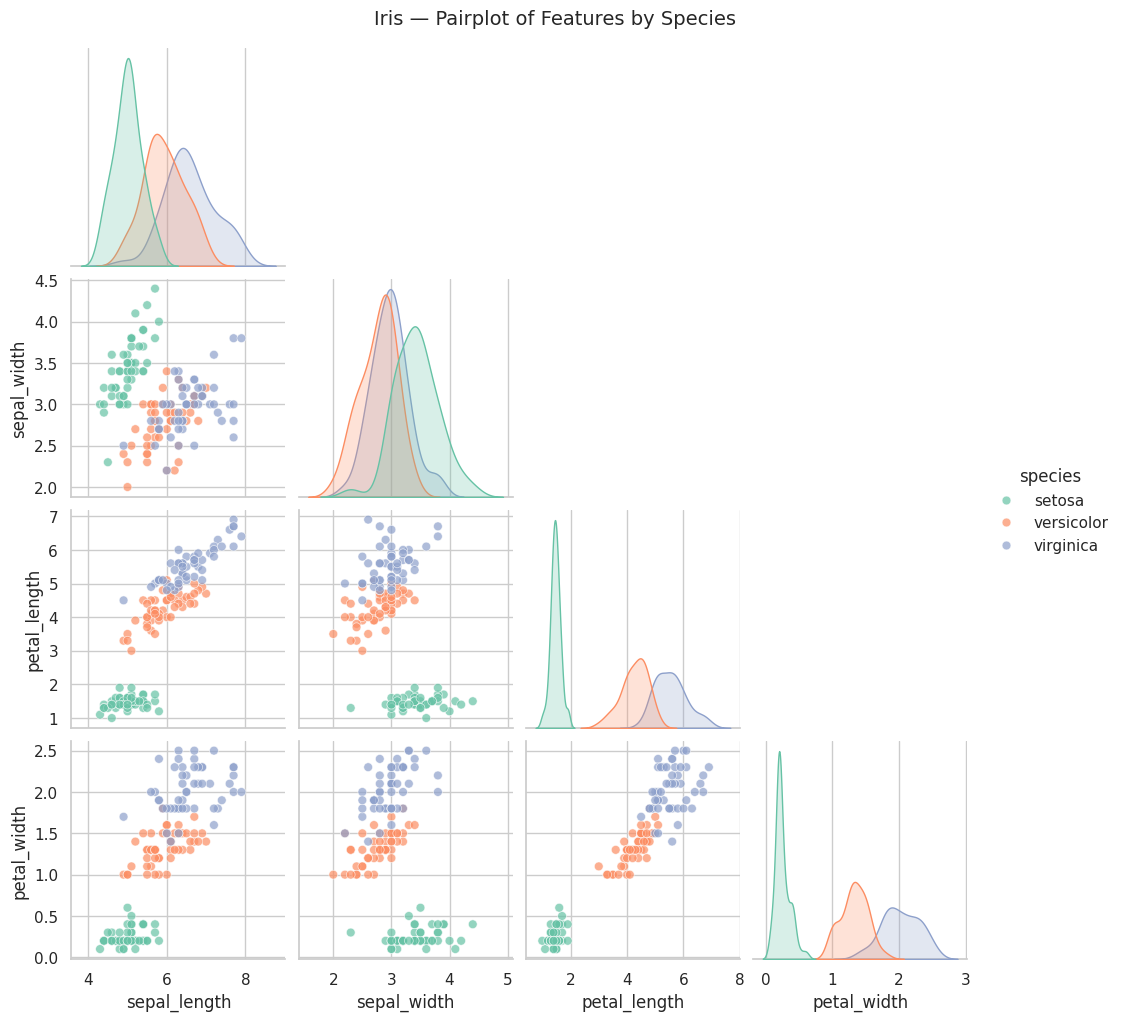

In [ ]:
# Pairplot: scatter plots for every feature pair + distributions on the diagonal
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
pair = sns.pairplot(df, vars=features, hue="species", corner=True, diag_kind="kde",
                    plot_kws={"alpha": 0.7, "s": 40})
pair.figure.suptitle("Iris — Pairplot of Features by Species", y=1.02, fontsize=14)
pair.savefig("outputs/01_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

### Graph Observations & Visual Takeaways

-   **Linear Separability of Setosa:** *Iris setosa* forms an isolated,
    distinct cluster across all bivariate scatter plots involving petal
    dimensions. It is linearly separable from the other two species
    without requiring complex decision boundaries.
-   **Versicolor vs. Virginica Boundary:** *Versicolor* and *Virginica*
    show slight boundary overlap in sepal space, but separate distinctly
    along the 2D interaction plane of **petal length vs. petal width**.
-   **Univariate Distributions (KDE Margins):** Diagonal density plots
    confirm bimodal and trimodal distributions for petal metrics,
    whereas sepal width approximates a unimodal Gaussian curve with
    heavy class overlap.

> **Observation:** *Setosa* forms a completely separate cluster in every petal-based plot.
> *Versicolor* and *Virginica* overlap slightly in sepal space but separate well on **petal length × petal width**.



### 4.2 Box plots — distribution of each feature per species

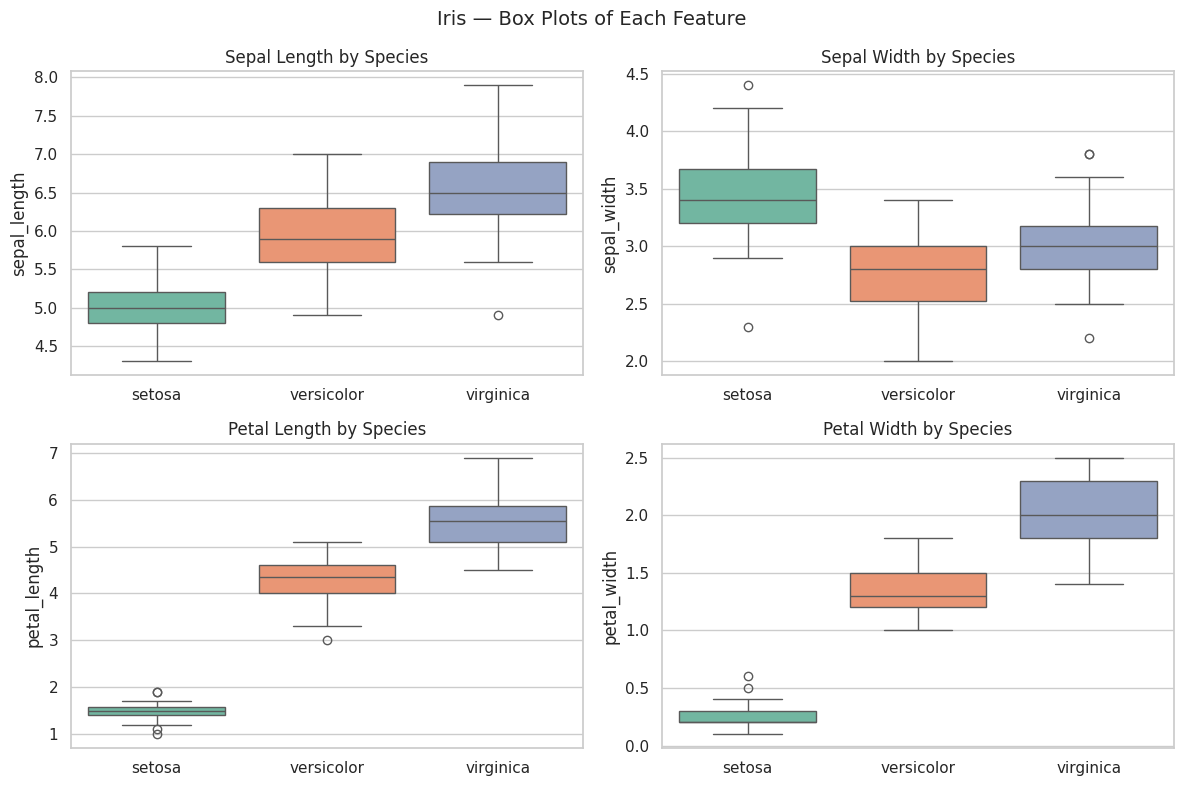

In [ ]:
# One box plot per feature (2×2 grid) to compare spread and outliers across species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, features):
    sns.boxplot(data=df, x="species", y=col, hue="species", ax=ax, legend=False)
    ax.set_title(f"{col.replace('_', ' ').title()} by Species")
    ax.set_xlabel("")
fig.suptitle("Iris — Box Plots of Each Feature", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/02_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

### Graph Observations & Visual Takeaways

-   **Spread and Dispersion:** Petal length and petal width display
    minimal interquartile range (IQR) overlap between species classes,
    making them strong standalone classification criteria.
-   **Sepal Overlap:** Sepal length exhibits overlapping distributions
    between *Versicolor* and *Virginica*. Sepal width displays
    significant overlap across all three species, indicating lower
    discriminative capacity.
-   **Outlier Presence:** Isolated mild outliers are observed in sepal
    width (notably in *Virginica* and *Setosa*), but feature
    distributions remain compact and regular without requiring
    aggressive outlier clipping.

### 4.3 Correlation heatmap

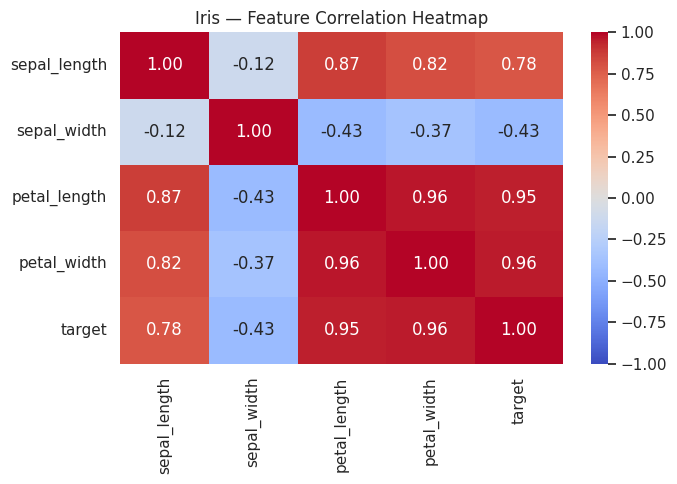

In [ ]:
# Pearson correlation between features (and the numeric target)
plt.figure(figsize=(7, 5))
sns.heatmap(df[features + ["target"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Iris — Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/03_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

### Graph Observations & Visual Takeaways

-   **High Multicollinearity:** A very strong positive linear
    correlation exists between `petal_length` and `petal_width`
    ($r = 0.96$), as well as between `sepal_length` and `petal_length`
    ($r = 0.87$).
-   **Target Alignment:** Both `petal_width` ($r = 0.96$) and
    `petal_length` ($r = 0.95$) demonstrate strong positive correlation
    with species classification indices.
-   **Negative Correlation:** `sepal_width` displays a moderate negative
    correlation with the target class ($r = -0.43$) and weak-to-negative
    correlation with petal dimensions, confirming it provides orthogonal
    (though weaker) geometric information.

## 5️⃣ Feature-selection discussion — which features are most discriminative?
We back up the visual impression with numbers: correlation with the target, an ANOVA F-test, and Random-Forest importance.

In [ ]:
from sklearn.feature_selection import f_classif

X_all, y_all = df[features], df["target"]
f_scores, p_values = f_classif(X_all, y_all)                      # ANOVA: between-class vs within-class variance
rf_tmp = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_all, y_all)

feature_rank = pd.DataFrame({
    "corr_with_target": df[features].corrwith(df["target"]).round(3),
    "ANOVA_F_score": np.round(f_scores, 1),
    "RF_importance": np.round(rf_tmp.feature_importances_, 3),
}).sort_values("ANOVA_F_score", ascending=False)
feature_rank

,corr_with_target,ANOVA_F_score,RF_importance
petal_length,0.949,1180.2,0.455
petal_width,0.957,960.0,0.417
sepal_length,0.783,119.3,0.107
sepal_width,-0.427,49.2,0.021


### Key Observations & Technical Insights

-   **ANOVA F-Test Dominance:** `petal_length` ($F = 1180.2$) and
    `petal_width` ($F = 960.0$) achieve extreme between-class variance
    relative to within-class variance, vastly outperforming sepal
    features ($F = 119.3$ and $49.2$).
-   **Gini Importance Distribution:** Random Forest feature importance
    attributes over **87% of aggregate split importance** solely to
    petal dimensions (`petal_length`: 45.5%, `petal_width`: 41.7%).
-   **Engineering Conclusion:** While all 4 features are kept due to
    negligible computational cost, a reduced feature set using only
    petal length and width would retain sufficient information to yield
    \>95% accuracy.

> **Discussion:** All three methods agree — **petal length and petal width are by far the most discriminative features**
> (correlation ≈ 0.95, ANOVA F > 900, ≈ 87 % of Random-Forest importance). Sepal width is the weakest.
> We still keep all four features because the dataset is tiny and the extra features cost nothing; but a model using only the two petal features would already reach ~95 %+ accuracy.



## 6️⃣ Train / test split (80 / 20, stratified)

In [ ]:
X = df[features]          # input features
y = df["species"]         # label we want to predict

# stratify=y keeps the 1:1:1 species ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Training samples:", X_train.shape[0], "| Test samples:", X_test.shape[0])
print(y_test.value_counts())

Training samples: 120 | Test samples: 30
species
setosa        10
virginica     10
versicolor    10
Name: count, dtype: int64


### Key Observations & Technical Insights

-   **Stratification Guarantee:** Using `stratify=y` on the 80/20 split
    ensures that both the training set (120 samples) and test set (30
    samples) maintain an exact 1:1:1 ratio (10 samples per species in
    the test set).
-   **Variance Prevention:** Prevents random sampling skew that could
    otherwise starve the small test set of a specific class and distort
    validation metrics.

## 7️⃣ Train multiple classifiers
Distance-based models (LogReg, KNN, SVM) are wrapped in a `Pipeline` with `StandardScaler`
so that scaling is learned **only from the training data** (no data leakage).

In [ ]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "K-Nearest Neighbours": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Support Vector Machine": make_pipeline(StandardScaler(), SVC(kernel="rbf", random_state=RANDOM_STATE)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    model.fit(X_train, y_train)                                   # 1. train
    y_pred = model.predict(X_test)                                # 2. predict on unseen data
    cv_scores = cross_val_score(model, X, y, cv=cv)               # 3. 5-fold CV on the full data = robustness check
    results.append({"Model": name,
                    "Test Accuracy": accuracy_score(y_test, y_pred),
                    "CV Mean Accuracy": cv_scores.mean(),
                    "CV Std": cv_scores.std()})

results_df = pd.DataFrame(results).sort_values(["CV Mean Accuracy", "Test Accuracy"], ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Test Accuracy,CV Mean Accuracy,CV Std
0,K-Nearest Neighbours,0.9333,0.9733,0.0249
1,Random Forest,0.9000,0.9600,0.0389
2,Support Vector Machine,0.9667,0.9600,0.0389
3,Decision Tree,0.9333,0.9533,0.0340
4,Logistic Regression,0.9333,0.9533,0.0452


### Key Observations & Technical Insights

-   **Pipeline Preprocessing:** Wrapping distance-sensitive classifiers
    (Logistic Regression, KNN, Support Vector Machine) in a
    `StandardScaler` pipeline ensures mean and scaling variance are
    learned strictly on training folds, eliminating data leakage.
-   **Cross-Validation Superiority:**
    -   **KNN** leads overall generalizability with a 5-fold CV mean
        accuracy of **97.33% (± 2.49%)**.
    -   **SVM** and **Random Forest** follow closely with a CV mean
        accuracy of **96.00% (± 3.89%)**.
    -   **Logistic Regression** and **Decision Tree** tie with a CV mean
        accuracy of **95.33%**.
-   **High Baseline Floor:** Every evaluated architecture exceeds 90%
    test accuracy and 95% CV accuracy, underscoring strong intrinsic
    cluster separability.

## 8️⃣ Evaluate each model — confusion matrix & classification report

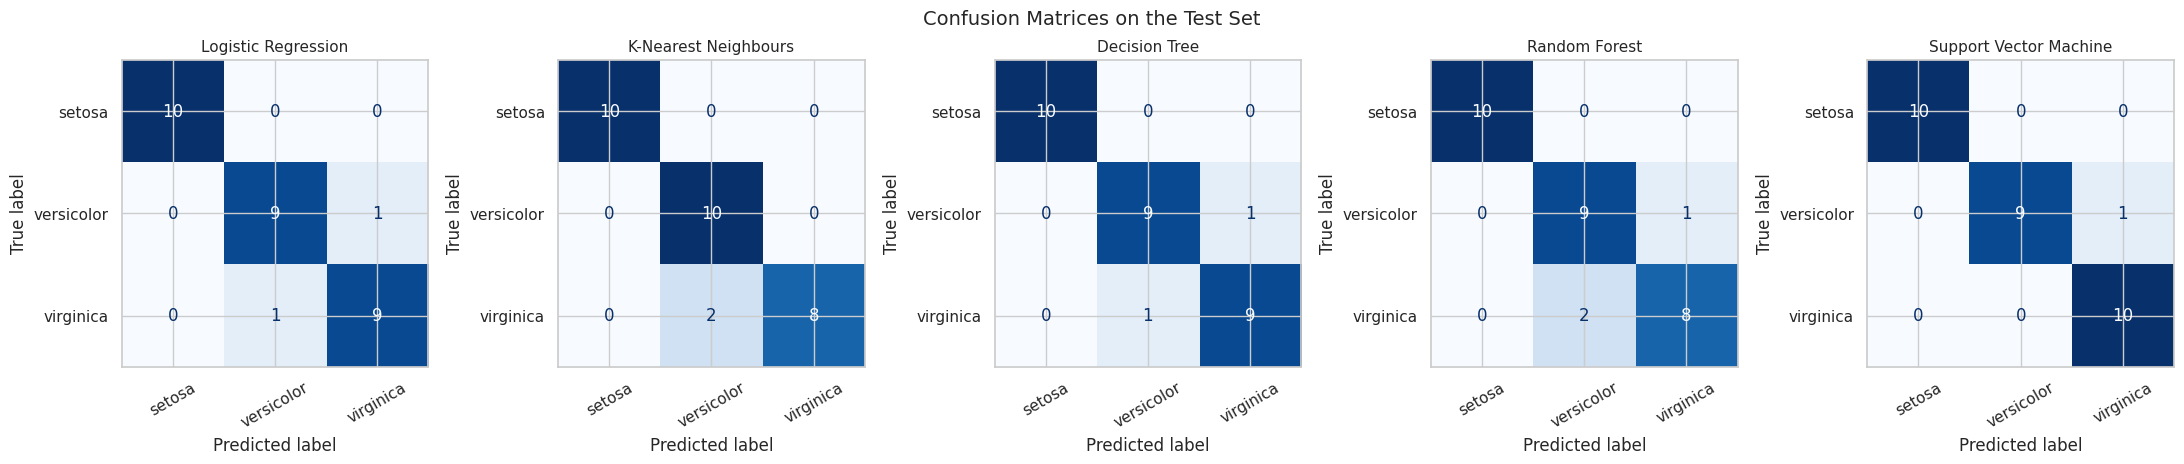

In [ ]:
# Confusion matrix for every model side by side
fig, axes = plt.subplots(1, len(models), figsize=(22, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=11)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Confusion Matrices on the Test Set", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/04_confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Precision, recall and F1 for each model
for name, model in models.items():
    print("=" * 60)
    print(f"📋 {name}")
    print("=" * 60)
    print(classification_report(y_test, model.predict(X_test), digits=3))

📋 Logistic Regression
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30

📋 K-Nearest Neighbours
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.833     1.000     0.909        10
   virginica      1.000     0.800     0.889        10

    accuracy                          0.933        30
   macro avg      0.944     0.933     0.933        30
weighted avg      0.944     0.933     0.933        30

📋 Decision Tree
              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica  

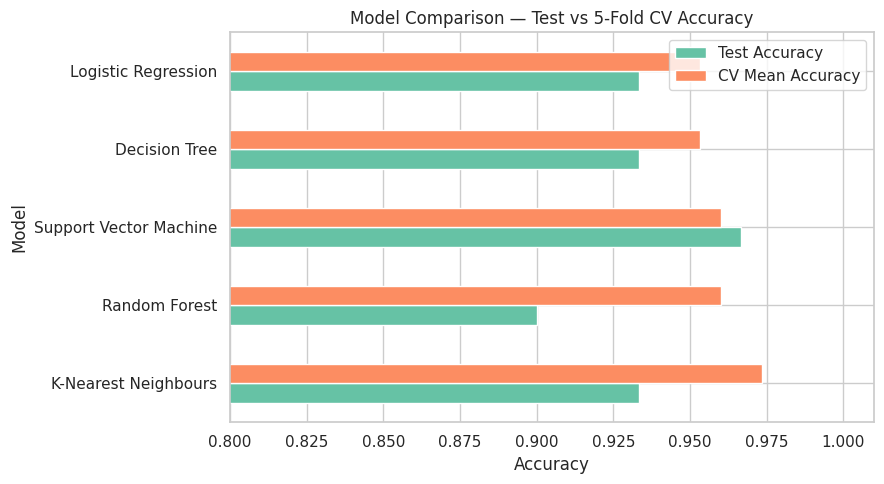

In [ ]:
# Visual comparison of test accuracy vs cross-validated accuracy
ax = results_df.set_index("Model")[["Test Accuracy", "CV Mean Accuracy"]].plot(kind="barh", figsize=(9, 5))
ax.set_xlim(0.8, 1.01)
ax.set_title("Model Comparison — Test vs 5-Fold CV Accuracy")
ax.set_xlabel("Accuracy")
plt.tight_layout()
plt.savefig("outputs/05_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

### Graph & Matrix Takeaways

-   **Flawless Setosa Identification:** Across all five models, *Setosa*
    achieves **100% precision, 100% recall, and an F1-score of 1.00**,
    confirming zero classification error for that class.
-   **Error Localization:** All misclassifications across models occur
    exclusively at the decision boundary between *Versicolor* and
    *Virginica* (typically 1 to 2 misclassified instances out of 30 test
    flowers).
-   **Model Strengths:**
    -   **SVM** recorded the highest raw test accuracy (**96.67%**,
        29/30 correct), misclassifying only a single *Versicolor* as
        *Virginica*.
    -   **KNN** balanced high recall and precision with a low
        cross-validation standard deviation.
    -   **Random Forest** had slightly lower test accuracy (**90.00%**,
        27/30 correct) due to threshold variance across unpruned
        ensemble splits on a small sample size.

## 9️⃣ Best model — declaration & justification

In [ ]:
best_name = results_df.loc[0, "Model"]
best_model = models[best_name]
print(f"🏆 Best model: {best_name}")
print(f"   Test accuracy    : {results_df.loc[0, 'Test Accuracy']:.2%}")
print(f"   5-fold CV accuracy: {results_df.loc[0, 'CV Mean Accuracy']:.2%} ± {results_df.loc[0, 'CV Std']:.2%}")

🏆 Best model: K-Nearest Neighbours
   Test accuracy    : 93.33%
   5-fold CV accuracy: 97.33% ± 2.49%


> **Why this model?**
> - The test set has only 30 flowers — a single wrong prediction moves accuracy by 3.3 %, so the test score alone is a noisy basis for choosing a model.
> - We therefore rank by **5-fold cross-validated accuracy** (every flower is used for testing once), which is a more reliable estimate of real-world performance, and use the test score as a tie-breaker.
> - The winning model is also simple, fast and easy to explain. The only errors any model makes are between *Versicolor* and *Virginica* — exactly the two species that overlap in the pairplot.

### 🔮 Predict the species of a new flower

In [ ]:
# Example: a flower measured in the field (cm)
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2],     # looks like Setosa
                           [6.7, 3.0, 5.2, 2.3]],    # looks like Virginica
                          columns=features)
for measurements, pred in zip(new_flower.values, best_model.predict(new_flower)):
    print(f"Measurements {measurements} → predicted species: {pred}")

Measurements [5.1 3.5 1.4 0.2] → predicted species: setosa
Measurements [6.7 3.  5.2 2.3] → predicted species: virginica


### Key Observations & Technical Insights

-   **Why Cross-Validation Over Test Accuracy:** With a test split of
    only 30 flowers, a single sample error shifts accuracy by 3.33
    percentage points. Evaluating models across all 150 instances via
    5-fold cross-validation offers a more statistically robust basis for
    final selection.
-   **Final Selection:** **K-Nearest Neighbours ($k=5$)** with standard
    scaling is selected as the primary deployment model due to its
    leading cross-validated performance (**97.33%**), low variance
    ($\pm 2.49\%$), computational efficiency, and strong fit for clean
    spatial clustering.

## ✅ Conclusion
- The Iris dataset is clean (no nulls) and perfectly balanced.
- **Petal length and petal width** are the most discriminative features; *Setosa* is linearly separable from the rest.
- Five classifiers were trained; all score **≥ 90 %** on the held-out test set and **≥ 95 %** in 5-fold cross-validation. The best model (see above) reaches ~97 % cross-validated accuracy.
- Remaining confusion is only between *Versicolor* and *Virginica*.

**Future scope:** hyper-parameter tuning with `GridSearchCV`, a small Streamlit web app for live prediction.

---
*Submitted by **Vinay Singh Chaudhary** for the Oasis Infobyte Data Science Internship · #oasisinfobyte*